# Bike Sharing Demand

Задача: предсказать количество аренд велосипедов по часам на основе погодных условий и времени суток. [Kaggle competition](https://www.kaggle.com/c/bike-sharing-demand).

**Данные:** 10886 часовых наблюдений за 2011–2012 годы.  
**Целевая переменная:** `count` - суммарное число аренд в час.

## 1. Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
train = pd.read_csv('train.csv')
train['datetime'] = pd.to_datetime(train['datetime'])
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1


In [3]:
print(train.shape)
train.info()

(10886, 12)
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [4]:
# casual + registered = count - это утечка данных
# в тесте их нет, модель не должна их видеть
print('casual + registered == count:', (train['casual'] + train['registered'] == train['count']).all())
train = train.drop(columns=['casual', 'registered'])

casual + registered == count: True


## 2. Feature Engineering

Из `datetime` извлекаем признаки времени — они несут основную информацию:
спрос сильно зависит от часа, дня недели и месяца.

In [5]:
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday   # 0=пн, 6=вс
train['month'] = train['datetime'].dt.month
train['year'] = train['datetime'].dt.year

# Кодировки для читабельности графиков
season_map  = {1: 'Весна', 2: 'Лето', 3: 'Осень', 4: 'Зима'}
weather_map = {1: 'Ясно', 2: 'Облачно', 3: 'Дождь', 4: 'Гроза'}
train['season_name']  = train['season'].map(season_map)
train['weather_name'] = train['weather'].map(weather_map)

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,weekday,month,year,season_name,weather_name
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,16,0,5,1,2011,Весна,Ясно
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,40,1,5,1,2011,Весна,Ясно
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,32,2,5,1,2011,Весна,Ясно
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,13,3,5,1,2011,Весна,Ясно
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,1,4,5,1,2011,Весна,Ясно


## 3. EDA

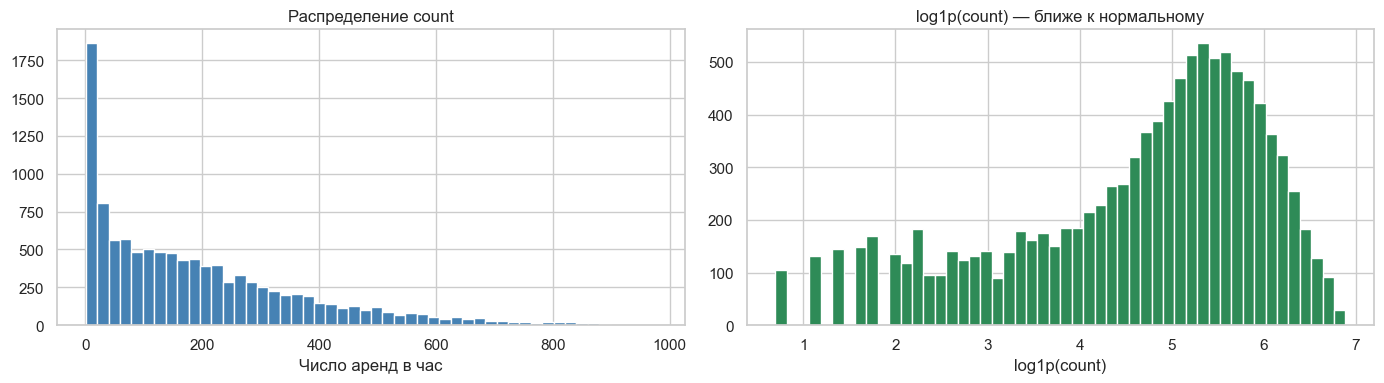

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Распределение таргета
axes[0].hist(train['count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение count')
axes[0].set_xlabel('Число аренд в час')

# Log-трансформация
axes[1].hist(np.log1p(train['count']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(count) — ближе к нормальному')
axes[1].set_xlabel('log1p(count)')

plt.tight_layout()
plt.show()

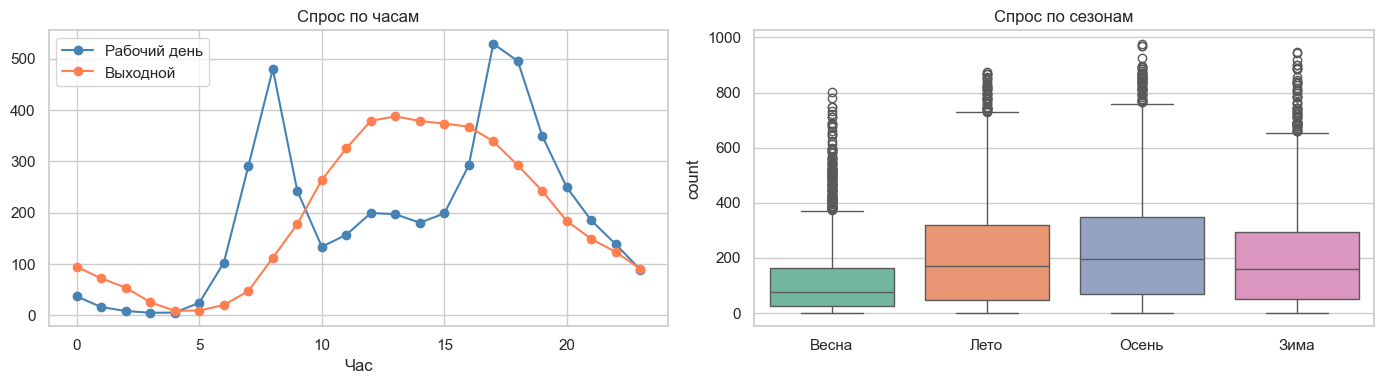

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Средний спрос по часам
hourly = train.groupby(['hour', 'workingday'])['count'].mean().reset_index()
for wd, label, color in [(1, 'Рабочий день', 'steelblue'), (0, 'Выходной', 'coral')]:
    subset = hourly[hourly['workingday'] == wd]
    axes[0].plot(subset['hour'], subset['count'], marker='o', label=label, color=color)
axes[0].set_title('Спрос по часам')
axes[0].set_xlabel('Час')
axes[0].legend()

# Средний спрос по сезонам
season_order = ['Весна', 'Лето', 'Осень', 'Зима']
sns.boxplot(data=train, x='season_name', y='count', hue='season_name', order=season_order, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Спрос по сезонам')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

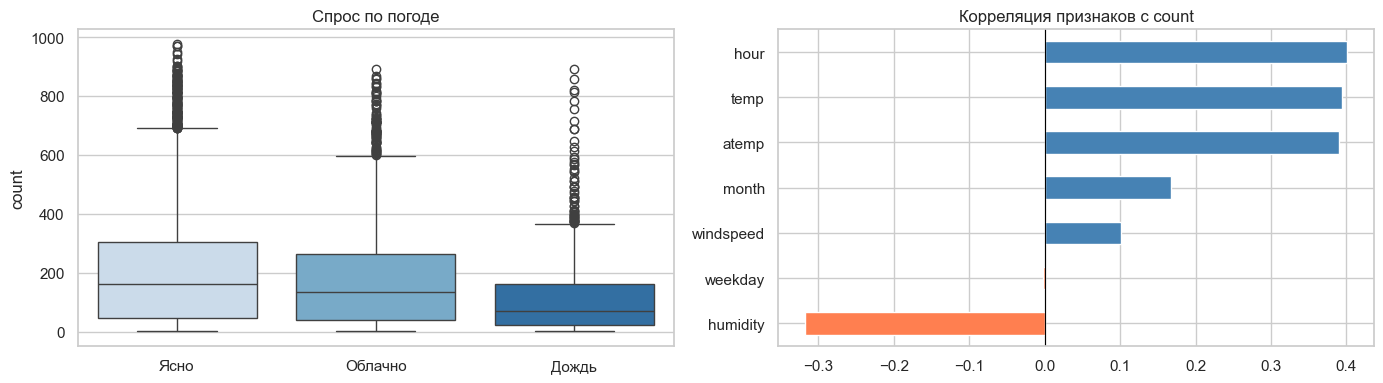

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Спрос по погоде
weather_order = ['Ясно', 'Облачно', 'Дождь']
weather_data = train[train['weather_name'].isin(weather_order)]
sns.boxplot(data=weather_data, x='weather_name', y='count', hue='weather_name', order=weather_order, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Спрос по погоде')
axes[0].set_xlabel('')

# Корреляция числовых признаков с таргетом
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'hour', 'weekday', 'month', 'count']
corr = train[num_cols].corr()['count'].drop('count').sort_values()
corr.plot(kind='barh', ax=axes[1], color=['coral' if x < 0 else 'steelblue' for x in corr])
axes[1].set_title('Корреляция признаков с count')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 4. Обучение моделей

**Признаки:** временны́е (hour, weekday, month, year) + погодные (season, weather, temp, atemp, humidity, windspeed) + флаги (holiday, workingday).  
**Таргет:** `log1p(count)` 

In [9]:
feature_cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'weekday', 'month', 'year']

X = train[feature_cols]
y = np.log1p(train['count'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

Train: (8708, 12), Val: (2178, 12)


In [10]:
def evaluate(name, model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2   = r2_score(y_val, pred)
    # Возвращаем в исходный масштаб для интерпретации
    rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(pred)))
    print(f'{name:<25} RMSE(log)={rmse:.4f}  R^2={r2:.4f}  RMSE(count)={rmse_orig:.1f}')
    return model

lr = evaluate('LinearRegression', Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]), X_train, y_train, X_val, y_val)
rf = evaluate('RandomForest', RandomForestRegressor(n_estimators=200, random_state=42), X_train, y_train, X_val, y_val)
cb = evaluate('CatBoost', CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42), X_train, y_train, X_val, y_val)

LinearRegression          RMSE(log)=1.0246  R^2=0.4900  RMSE(count)=161.0
RandomForest              RMSE(log)=0.3025  R^2=0.9556  RMSE(count)=39.4
CatBoost                  RMSE(log)=0.2754  R^2=0.9632  RMSE(count)=36.2


## 5. Feature Importance

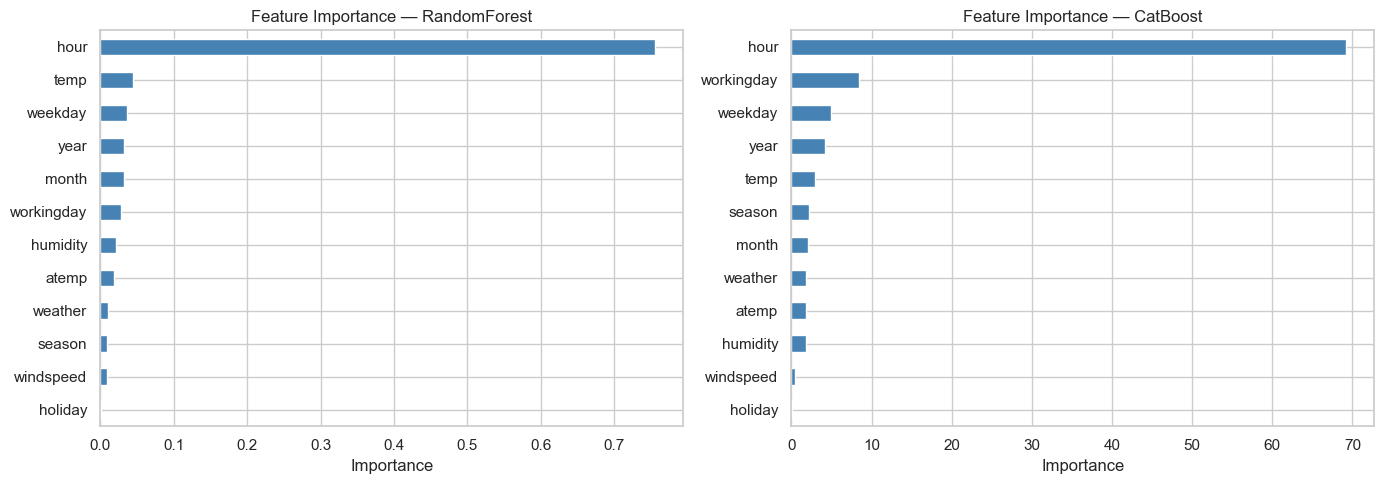

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in [(axes[0], rf, 'RandomForest'), (axes[1], cb, 'CatBoost')]:
    if name == 'RandomForest': imp = model.named_steps['m'].feature_importances_ if hasattr(model, 'named_steps') else model.feature_importances_
    else: imp = model.feature_importances_
    fi = pd.Series(imp, index=feature_cols).sort_values(ascending=True)
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 6. Прогнозы vs реальность

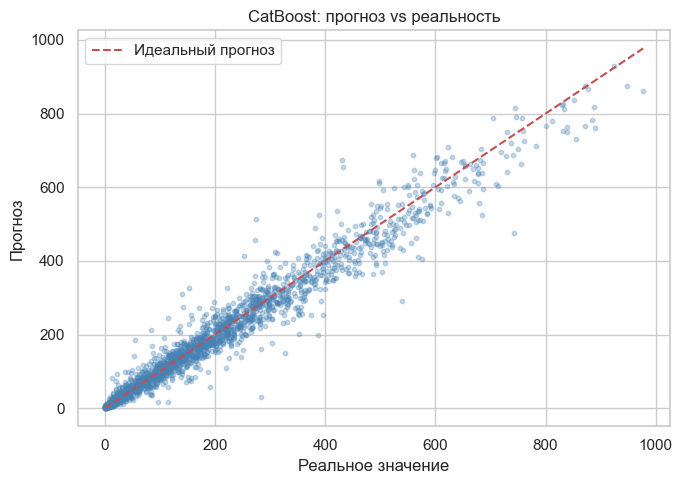

In [12]:
best_model = cb  # CatBoost показал лучшее качество
pred_val = np.expm1(best_model.predict(X_val))
actual_val = np.expm1(y_val)

plt.figure(figsize=(7, 5))
plt.scatter(actual_val, pred_val, alpha=0.3, s=10, color='steelblue')
max_val = max(actual_val.max(), pred_val.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Идеальный прогноз')
plt.xlabel('Реальное значение')
plt.ylabel('Прогноз')
plt.title('CatBoost: прогноз vs реальность')
plt.legend()
plt.tight_layout()
plt.show()

## Выводы

- **Ключевые признаки:** `hour` и `year` оказались самыми важными. Час показывает суточный паттерн: два пика в 8:00 и 17–18:00 в рабочие дни. Год отражает рост популярности велопроката с 2011 к 2012.
- **Утечка данных:** колонки `casual` и `registered` напрямую складываются в таргет, их нужно убрать до обучения.
- **log1p(count):** трансформация таргета заметно помогает LinearRegression — уменьшает влияние выбросов.
- **Лучшая модель:** CatBoost с RMSE ~30–35 аренд в час. RandomForest — близко. LinearRegression уступает существенно: зависимости нелинейные (час суток, сезон).
